### **Project Focus Idea:**

By taking a deep analyzation based on the data provided in the dataset, we can find out which regions and products are performing best in term of sales. After that, suggest recommended strategies to imporve sales through segmentation and targeting marketing

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

## Step 1: Data Preparation

### 1. Load the Dataset

In [2]:
nike_data = pd.read_csv('Nike Dataset.csv')
nike_data.head(5)

,Invoice Date,Product,Region,Retailer,Sales Method,State,Price per Unit,Total Sales,Units Sold
0,01-01-2020,Men's Street Footwear,Northeast,Foot Locker,In-store,New York,50,6000,120
1,02-01-2020,Men's Athletic Footwear,Northeast,Foot Locker,In-store,New York,50,5000,100
2,03-01-2020,Women's Street Footwear,Northeast,Foot Locker,In-store,New York,40,4000,100
3,04-01-2020,Women's Athletic Footwear,Northeast,Foot Locker,In-store,New York,45,3825,85
4,05-01-2020,Men's Apparel,Northeast,Foot Locker,In-store,New York,60,5400,90


In [3]:
# rename the columns labels and make them lowercase
nike_data.columns = nike_data.columns.str.strip().str.lower().str.replace(' ','_')
nike_data.columns

Index(['invoice_date', 'product', 'region', 'retailer', 'sales_method',
       'state', 'price_per_unit', 'total_sales', 'units_sold'],
      dtype='object')

| **Column Name**       | **Description**                                                                   |
|-----------------------|-----------------------------------------------------------------------------------|
| **invoice_date**      | The date when the sales transaction occurred                                      |
| **product**           | Describes the type of Nike product sold                                           |
| **region**            | Indicates the geographical region where the sale took place                       |
| **retailer**          | Specifies the retailer that sold the product                                      |
| **sales_method**      | Describes the method through which the product was sold                           |
| **state**             | Indicates the specific state where the sale occurred                              |
| **price_per_unit**    | The price of one unit of the product                                              |
| **total_sales**       | The total revenue generated from the sale of the product in a particular transaction |

### 2. Data Cleaning

In [4]:
# Check for missing value
nike_data.isna().sum()

invoice_date      0
product           0
region            0
retailer          0
sales_method      0
state             0
price_per_unit    0
total_sales       0
units_sold        0
dtype: int64

In [5]:
nike_data.duplicated().sum()

0

In [6]:
nike_data.dtypes

invoice_date      object
product           object
region            object
retailer          object
sales_method      object
state             object
price_per_unit     int64
total_sales        int64
units_sold         int64
dtype: object

In [7]:
nike_data['invoice_date'] = pd.to_datetime(nike_data['invoice_date'], errors='coerce')
nike_data.dtypes

invoice_date      datetime64[ns]
product                   object
region                    object
retailer                  object
sales_method              object
state                     object
price_per_unit             int64
total_sales                int64
units_sold                 int64
dtype: object

## Step 2: Exploratory Data Analysis (EDA)

Goal: Understand the overall data, key trends, and structure before diving into specific regions.

Key Areas:
- Total sales by region, product, and sales method.
- Units sold by region and product.
- Average price per unit: Calculate to understand pricing strategy across products and regions.

### 1. Transform Data

In [8]:
# Create 'average_price_per_unit'
nike_data['average_price_per_unit'] = nike_data['total_sales'] / nike_data['units_sold']
nike_data.head(5)


,invoice_date,product,region,retailer,sales_method,state,price_per_unit,total_sales,units_sold,average_price_per_unit
0,2020-01-01,Men's Street Footwear,Northeast,Foot Locker,In-store,New York,50,6000,120,50.0
1,2020-02-01,Men's Athletic Footwear,Northeast,Foot Locker,In-store,New York,50,5000,100,50.0
2,2020-03-01,Women's Street Footwear,Northeast,Foot Locker,In-store,New York,40,4000,100,40.0
3,2020-04-01,Women's Athletic Footwear,Northeast,Foot Locker,In-store,New York,45,3825,85,45.0
4,2020-05-01,Men's Apparel,Northeast,Foot Locker,In-store,New York,60,5400,90,60.0


In [9]:
# Group data for sales overview
sales_overview = nike_data.groupby('invoice_date').agg({
    'total_sales': 'sum',
    'units_sold': 'sum',
    'average_price_per_unit': 'mean'
}).reset_index()
sales_overview.head(5)

,invoice_date,total_sales,units_sold,average_price_per_unit
0,2020-01-01,8452,236,24.045500
1,2020-01-02,9141,259,21.399843
2,2020-01-03,2377,52,26.650253
3,2020-01-04,1974,45,29.950000
4,2020-01-05,9257,191,32.654130


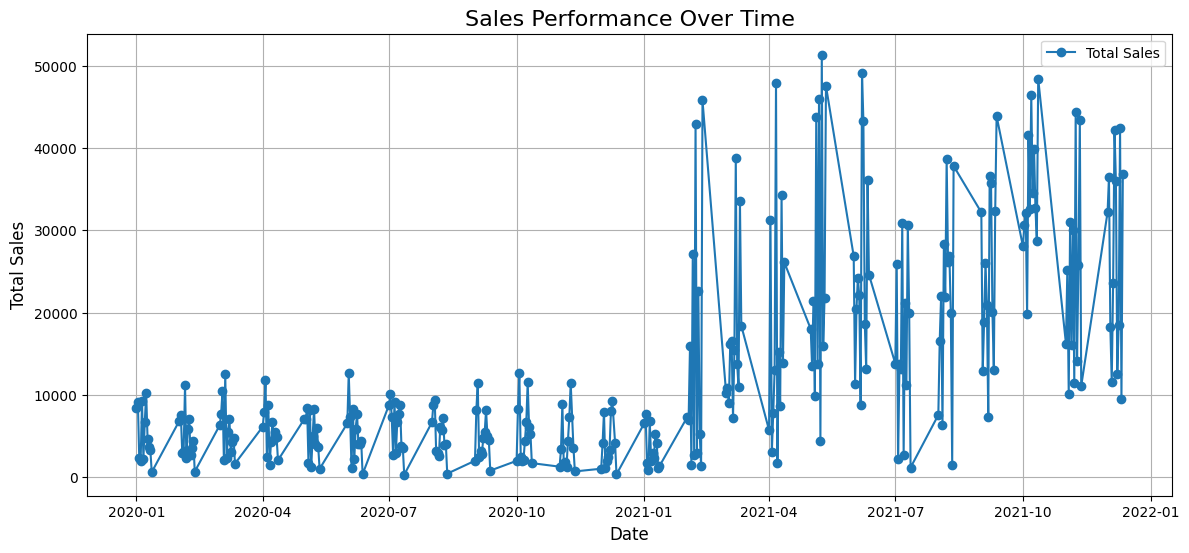

In [10]:
# Plot sales performance over time
plt.figure(figsize=(14, 6))
plt.plot(sales_overview['invoice_date'], 
         sales_overview['total_sales'], label='Total Sales', marker='o')
plt.title('Sales Performance Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

In [11]:
sales_overview = nike_data.groupby([nike_data['invoice_date'].dt.to_period('M')]).agg(
    total_sales=('total_sales', 'sum')
).reset_index()
sales_overview['invoice_date'] = sales_overview['invoice_date'].dt.to_timestamp()


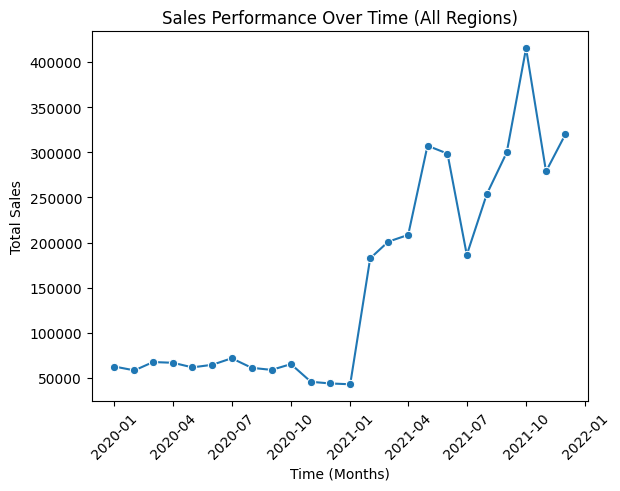

In [12]:
# Convert 'invoice_date' back to datetime after grouping by month
sales_overview = nike_data.groupby([nike_data['invoice_date'].dt.to_period('M')]).agg(
    total_sales=('total_sales', 'sum')
).reset_index()
sales_overview['invoice_date'] = sales_overview['invoice_date'].dt.to_timestamp()

# Plot sales over time for the 'West' region
sns.lineplot(data=sales_overview, x='invoice_date', y='total_sales', marker='o')

plt.title("Sales Performance Over Time (All Regions)")
plt.xlabel("Time (Months)")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


In [13]:
# Top and Bottom Performing Regions
region_performance = nike_data.groupby('region').agg({
    'total_sales': 'sum',
    'units_sold': 'sum'
}).reset_index().sort_values(by='total_sales', ascending=False)
region_performance

,region,total_sales,units_sold
4,West,2329193,61832
1,Northeast,1863429,50435
3,Southeast,1631786,40873
2,South,1446722,49439
0,Midwest,1358145,39405


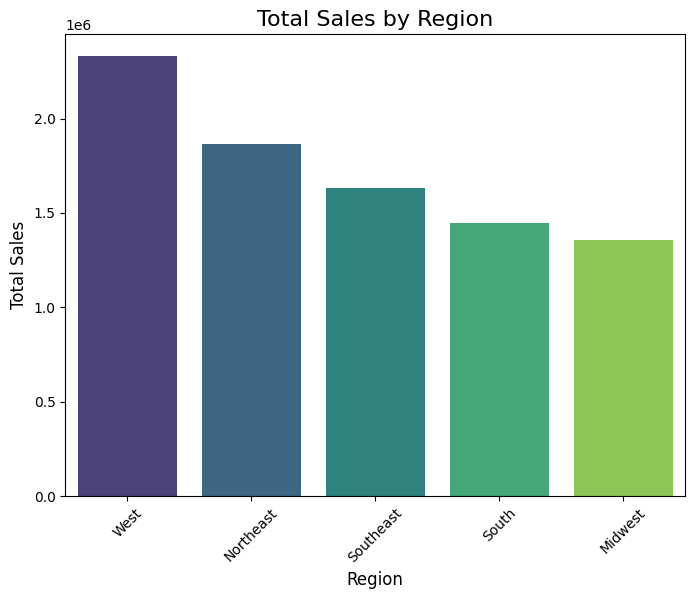

In [14]:
# Bar Chart for Regional Performance
plt.figure(figsize=(8, 6))
sns.barplot(x='region', y='total_sales', data=region_performance, hue='region', palette='viridis')
plt.title('Total Sales by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [15]:
# Sales Channels Analysis
channel_performance = nike_data.groupby('sales_method').agg({
    'total_sales': 'sum',
    'units_sold': 'sum'
}).reset_index().sort_values(by='total_sales', ascending=False)
channel_performance

,sales_method,total_sales,units_sold
0,In-store,3566650,69401
2,Outlet,2595011,79706
1,Online,2467614,92877


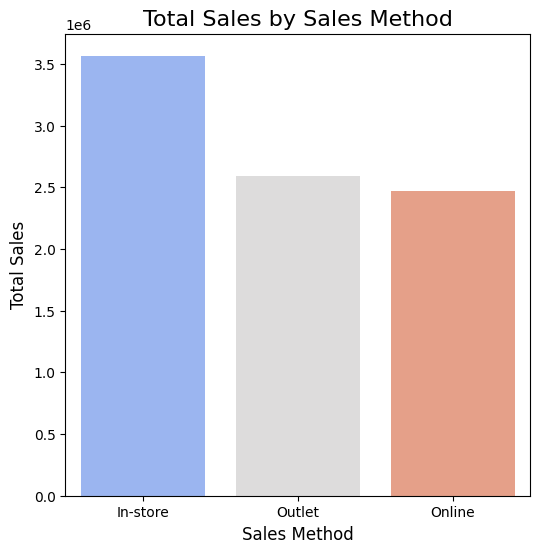

In [16]:
# Bar Chart for Sales Channels
plt.figure(figsize=(6, 6))
sns.barplot(x='sales_method', y='total_sales', data=channel_performance, hue='sales_method', 
            palette='coolwarm')
plt.title('Total Sales by Sales Method', fontsize=16)
plt.xlabel('Sales Method', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.show()

## Step 3: Regional Analysis

### 1. West Region

#### 1.1. Sales Overtime

In [17]:
# Filter data for the 'West' region
west_data = nike_data[nike_data['region'] == 'West']
west_data.head(2)

,invoice_date,product,region,retailer,sales_method,state,price_per_unit,total_sales,units_sold,average_price_per_unit
144,2020-05-11,Men's Apparel,West,West Gear,Outlet,California,55,3163,58,54.534483
145,2020-06-11,Women's Apparel,West,West Gear,Outlet,California,50,3875,78,49.679487


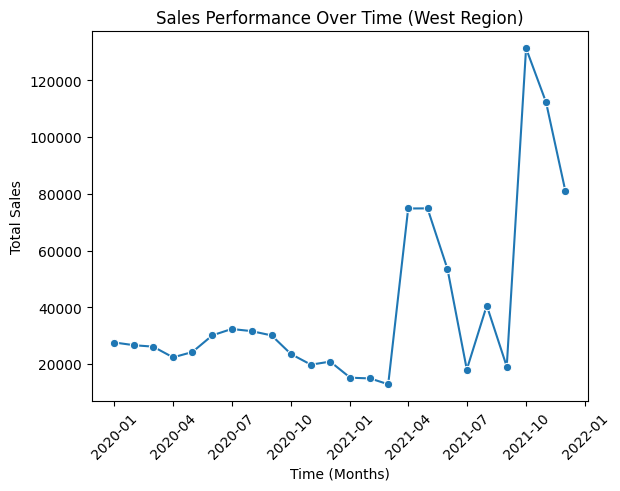

In [18]:
# Convert 'invoice_date' back to datetime after grouping by month
west_region_monthly_sales = west_data.groupby([west_data['invoice_date'].dt.to_period('M')]).agg(
    total_sales=('total_sales', 'sum')
).reset_index()
west_region_monthly_sales['invoice_date'] = west_region_monthly_sales['invoice_date'].dt.to_timestamp()

# Plot sales over time for the 'West' region
sns.lineplot(data=west_region_monthly_sales, x='invoice_date', y='total_sales', marker='o')

plt.title("Sales Performance Over Time (West Region)")
plt.xlabel("Time (Months)")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


#### 1.2. Top and Bottom Products Performance

Goal: Identify top-selling products and underperforming products in the region.

Focus: Tailoring marketing strategies to push top-performing products and promote underperforming ones.

In [19]:
# Group sales by product
west_product_performance = west_data.groupby('product').agg(
    total_sales=('total_sales', 'sum'),
    total_units=('units_sold', 'sum')
).reset_index()

# Identify top and bottom products
west_top_products = west_product_performance.sort_values('total_sales', ascending=False).head(10)
west_top_products

,product,total_sales,total_units
2,Men's Street Footwear,460998,13327
3,Women's Apparel,452086,10497
1,Men's Athletic Footwear,431365,11486
5,Women's Street Footwear,369830,10277
0,Men's Apparel,312256,7692
4,Women's Athletic Footwear,302658,8553


#### 1.3. Top and Bottom Sales Method Performance

Goal: Identify the most effective sales channels (In-store, Online, Outlet) in the region.

Focus: Determine where customers prefer to shop (online vs. in-store) and adjust marketing accordingly.

In [20]:
# Sales method performance
west_sales_method_performance = west_data.groupby('sales_method').agg(
    total_sales=('total_sales', 'sum'),
    total_units=('units_sold', 'sum')
).reset_index()
west_sales_method_performance

,sales_method,total_sales,total_units
0,In-store,1053877,18933
1,Online,581238,21533
2,Outlet,694078,21366


#### 1.4. Top and Bottom States Performance

In [21]:
# Group sales by state
west_state_summary = west_data.groupby('state').agg(
    total_sales=('total_sales', 'sum'),
    total_units=('units_sold', 'sum')
).reset_index()

# Identify top and bottom states by sales
west_top_states = west_state_summary.sort_values('total_sales', ascending=False).head(5)
print ('Top states:')
west_top_states

Top states:


,state,total_sales,total_units
1,California,601768,16372
8,Washington,263318,4686
6,Oregon,213509,5077
2,Colorado,209975,4164
4,Nevada,208586,5201


In [22]:
west_bottom_states = west_state_summary.sort_values('total_sales', ascending=True).head(5)

print ('Bottom states:')
west_bottom_states

Bottom states:


,state,total_sales,total_units
7,Utah,96972,4867
0,Arizona,157840,4726
9,Wyoming,185783,5042
3,Idaho,192778,6414
5,New Mexico,198664,5283


### 2. Northeast Region

#### 2.1. Sales Overtime

In [23]:
# Filter data for the 'Northeast' region
northeast_data = nike_data[nike_data['region'] == 'Northeast']
northeast_data.head(2)

,invoice_date,product,region,retailer,sales_method,state,price_per_unit,total_sales,units_sold,average_price_per_unit
0,2020-01-01,Men's Street Footwear,Northeast,Foot Locker,In-store,New York,50,6000,120,50.0
1,2020-02-01,Men's Athletic Footwear,Northeast,Foot Locker,In-store,New York,50,5000,100,50.0


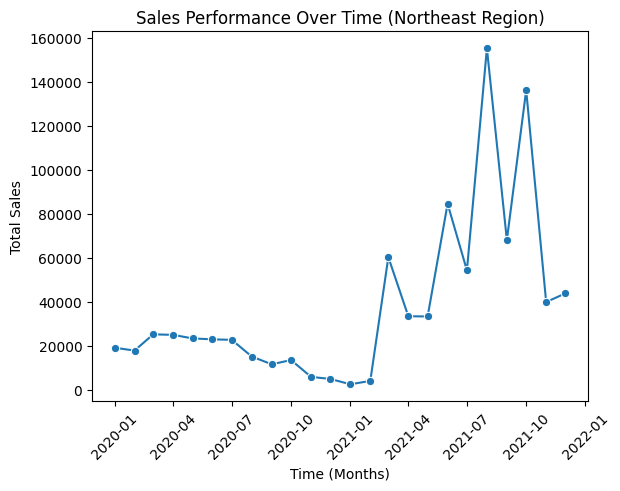

In [24]:
# Convert 'invoice_date' back to datetime after grouping by month
northeast_region_monthly_sales = northeast_data.groupby([northeast_data['invoice_date'].dt.to_period('M')]).agg(
    total_sales=('total_sales', 'sum')
).reset_index()
northeast_region_monthly_sales['invoice_date'] = northeast_region_monthly_sales['invoice_date'].dt.to_timestamp()

# Plot sales over time for the 'Northeast' region
sns.lineplot(data=northeast_region_monthly_sales, x='invoice_date', y='total_sales', marker='o')

plt.title("Sales Performance Over Time (Northeast Region)")
plt.xlabel("Time (Months)")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


#### 2.2. Top and Bottom Products Performance

Goal: Identify top-selling products and underperforming products in the region.

Focus: Tailoring marketing strategies to push top-performing products and promote underperforming ones.

In [25]:
# Group sales by product
northeast_product_performance = northeast_data.groupby('product').agg(
    total_sales=('total_sales', 'sum'),
    total_units=('units_sold', 'sum')
).reset_index()

# Identify top and bottom products
northeast_top_products = northeast_product_performance.sort_values('total_sales', ascending=False).head(10)
northeast_top_products

,product,total_sales,total_units
2,Men's Street Footwear,510281,13477
3,Women's Apparel,375453,9050
1,Men's Athletic Footwear,288773,8204
0,Men's Apparel,257478,6249
5,Women's Street Footwear,233448,7457
4,Women's Athletic Footwear,197996,5998


#### 2.3. Top and Bottom Sales Method Performance

In [26]:
# Sales method performance
northeast_sales_method_performance = northeast_data.groupby('sales_method').agg(
    total_sales=('total_sales', 'sum'),
    total_units=('units_sold', 'sum')
).reset_index()
northeast_sales_method_performance

,sales_method,total_sales,total_units
0,In-store,1159610,23172
1,Online,46305,9474
2,Outlet,657514,17789


#### 2.4. Top and Bottom States Performance

In [27]:
# Group sales by state
northeast_state_summary = northeast_data.groupby('state').agg(
    total_sales=('total_sales', 'sum'),
    total_units=('units_sold', 'sum')
).reset_index()
print('Top states:')

# Identify top and bottom states by sales
northeast_top_states = northeast_state_summary.sort_values('total_sales', ascending=False).head(5)
northeast_top_states

Top states:


,state,total_sales,total_units
7,New York,642317,16959
5,New Hampshire,164133,4107
10,Vermont,143540,3903
1,Delaware,123000,3052
0,Connecticut,115760,3488


In [28]:
northeast_bottom_states = northeast_state_summary.sort_values('total_sales', ascending=True).head(5)
print('Bottom states:')
northeast_bottom_states

Bottom states:


,state,total_sales,total_units
3,Maryland,77591,2103
9,Rhode Island,84483,2773
2,Maine,91974,2260
6,New Jersey,99353,2673
8,Pennsylvania,103590,2788


### 3. Southeast Region

#### 3.1. Sales Overtime

In [29]:
# Filter data for the 'West' region
southeast_data = nike_data[nike_data['region'] == 'Southeast']
southeast_data.head(2)


,invoice_date,product,region,retailer,sales_method,state,price_per_unit,total_sales,units_sold,average_price_per_unit
720,2020-10-08,Men's Apparel,Southeast,Foot Locker,In-store,Florida,55,4125,75,55.0
721,2020-11-08,Women's Apparel,Southeast,Foot Locker,In-store,Florida,45,3825,85,45.0


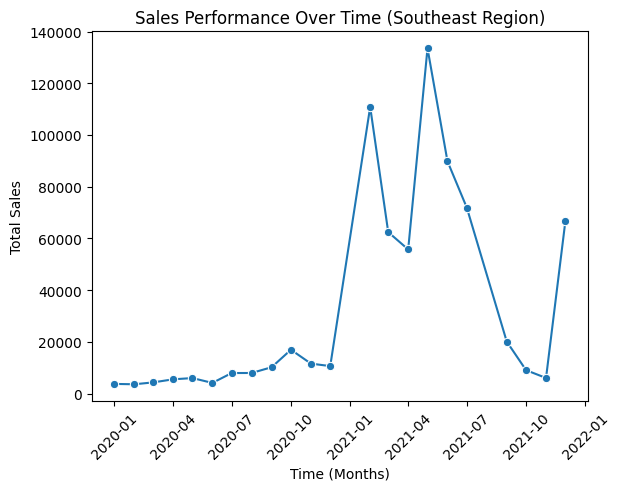

In [30]:
# Convert 'invoice_date' back to datetime after grouping by month
southeast_region_monthly_sales = southeast_data.groupby([southeast_data['invoice_date'].dt.to_period('M')]).agg(
    total_sales=('total_sales', 'sum')
).reset_index()
southeast_region_monthly_sales['invoice_date'] = southeast_region_monthly_sales['invoice_date'].dt.to_timestamp()

# Plot sales over time for the 'West' region
sns.lineplot(data=southeast_region_monthly_sales, x='invoice_date', y='total_sales', marker='o')

plt.title("Sales Performance Over Time (Southeast Region)")
plt.xlabel("Time (Months)")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


#### 3.2. Top and Bottom Products Performance

In [31]:
# Group sales by product
southeast_product_performance = southeast_data.groupby('product').agg(
    total_sales=('total_sales', 'sum'),
    total_units=('units_sold', 'sum')
).reset_index()

# Identify top and bottom products
southeast_top_products = southeast_product_performance.sort_values('total_sales', ascending=False).head(10)
southeast_top_products


,product,total_sales,total_units
2,Men's Street Footwear,360206,9215
3,Women's Apparel,314924,6913
1,Men's Athletic Footwear,277784,7140
0,Men's Apparel,244623,5468
5,Women's Street Footwear,231208,6585
4,Women's Athletic Footwear,203041,5552


#### 3.3. Top and Bottom Sales Method Performance

In [32]:
# Sales method performance
southeast_sales_method_performance = southeast_data.groupby('sales_method').agg(
    total_sales=('total_sales', 'sum'),
    total_units=('units_sold', 'sum')
).reset_index()
southeast_sales_method_performance


,sales_method,total_sales,total_units
0,In-store,723634,11984
1,Online,839047,24570
2,Outlet,69105,4319


#### 3.4. Top and Bottom States Performance

In [33]:
# Group sales by state
southeast_state_summary = southeast_data.groupby('state').agg(
    total_sales=('total_sales', 'sum'),
    total_units=('units_sold', 'sum')
).reset_index()

# Identify top and bottom states by sales
southeast_top_states = southeast_state_summary.sort_values('total_sales', ascending=False).head(5)
print ('Top states:')
southeast_top_states


Top states:


,state,total_sales,total_units
0,Florida,592866,13386
4,South Carolina,292868,7290
3,North Carolina,239574,6318
5,Virginia,215753,5318
1,Georgia,189988,5667


In [34]:
southeast_bottom_states = southeast_state_summary.sort_values('total_sales', ascending=True).head(5)
print ('Bottom states:')
southeast_bottom_states

Bottom states:


,state,total_sales,total_units
2,Kentucky,100737,2894
1,Georgia,189988,5667
5,Virginia,215753,5318
3,North Carolina,239574,6318
4,South Carolina,292868,7290


### 4. South Region

#### 4.1. Sales Overtime

In [35]:
# Filter data for the 'West' region
south_data = nike_data[nike_data['region'] == 'South']
south_data.head(2)


,invoice_date,product,region,retailer,sales_method,state,price_per_unit,total_sales,units_sold,average_price_per_unit
72,NaT,Men's Apparel,South,Sports Direct,Outlet,Texas,40,2200,55,40.0
73,NaT,Women's Apparel,South,Sports Direct,Outlet,Texas,35,2450,70,35.0


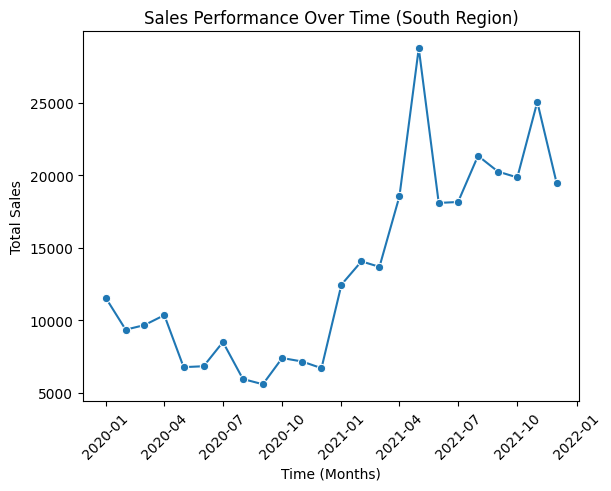

In [36]:
# Convert 'invoice_date' back to datetime after grouping by month
south_region_monthly_sales = south_data.groupby([south_data['invoice_date'].dt.to_period('M')]).agg(
    total_sales=('total_sales', 'sum')
).reset_index()
south_region_monthly_sales['invoice_date'] = south_region_monthly_sales['invoice_date'].dt.to_timestamp()

# Plot sales over time for the 'West' region
sns.lineplot(data=south_region_monthly_sales, x='invoice_date', y='total_sales', marker='o')

plt.title("Sales Performance Over Time (South Region)")
plt.xlabel("Time (Months)")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


#### 4.2. Top and Bottom Products Performance

In [37]:
# Group sales by product
south_product_performance = south_data.groupby('product').agg(
    total_sales=('total_sales', 'sum'),
    total_units=('units_sold', 'sum')
).reset_index()

# Identify top and bottom products
south_top_products = south_product_performance.sort_values('total_sales', ascending=False).head(10)
south_top_products


,product,total_sales,total_units
3,Women's Apparel,296081,8905
2,Men's Street Footwear,284459,10690
1,Men's Athletic Footwear,257118,9049
5,Women's Street Footwear,227794,8260
0,Men's Apparel,197045,6104
4,Women's Athletic Footwear,184225,6431


#### 4.3. Top and Bottom Sales Method Performance

In [38]:
# Sales method performance
south_sales_method_performance = south_data.groupby('sales_method').agg(
    total_sales=('total_sales', 'sum'),
    total_units=('units_sold', 'sum')
).reset_index()
south_sales_method_performance


,sales_method,total_sales,total_units
0,In-store,33941,688
1,Online,598434,20600
2,Outlet,814347,28151


#### 4.4. Top and Bottom States Performance

In [39]:
# Group sales by state
south_state_summary = south_data.groupby('state').agg(
    total_sales=('total_sales', 'sum'),
    total_units=('units_sold', 'sum')
).reset_index()

# Identify top and bottom states by sales
south_top_states = south_state_summary.sort_values('total_sales', ascending=False).head(5)
print ('Top states:')
south_top_states


Top states:


,state,total_sales,total_units
6,Texas,463613,16004
2,Louisiana,237520,5791
5,Tennessee,180689,6629
0,Alabama,176347,6360
3,Mississippi,155927,5714


In [40]:
south_bottom_states = west_state_summary.sort_values('total_sales', ascending=True).head(5)
print ('Bottom states:')
south_bottom_states


Bottom states:


,state,total_sales,total_units
7,Utah,96972,4867
0,Arizona,157840,4726
9,Wyoming,185783,5042
3,Idaho,192778,6414
5,New Mexico,198664,5283


### 5. Midwest Region

#### 5.1. Sales Overtime

In [41]:
# Filter data for the 'West' region
midwest_data = nike_data[nike_data['region'] == 'Midwest']
midwest_data.head(2)

,invoice_date,product,region,retailer,sales_method,state,price_per_unit,total_sales,units_sold,average_price_per_unit
288,2021-04-06,Men's Apparel,Midwest,Foot Locker,Outlet,Illinois,55,963,18,53.500000
289,2021-05-06,Women's Apparel,Midwest,Foot Locker,Outlet,Illinois,45,1238,28,44.214286


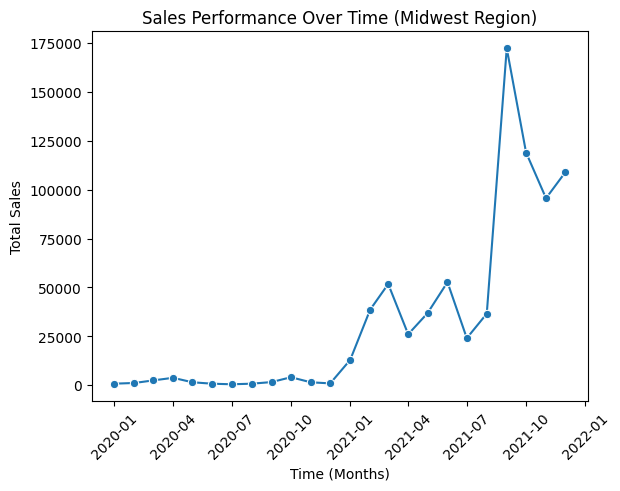

In [42]:
# Convert 'invoice_date' back to datetime after grouping by month
midwest_region_monthly_sales = midwest_data.groupby([midwest_data['invoice_date'].dt.to_period('M')]).agg(
    total_sales=('total_sales', 'sum')
).reset_index()
midwest_region_monthly_sales['invoice_date'] = midwest_region_monthly_sales['invoice_date'].dt.to_timestamp()

# Plot sales over time for the 'West' region
sns.lineplot(data=midwest_region_monthly_sales, x='invoice_date', y='total_sales', marker='o')

plt.title("Sales Performance Over Time (Midwest Region)")
plt.xlabel("Time (Months)")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


#### 5.2. Top and Bottom Products Performance

In [43]:
# Group sales by product
midwest_product_performance = midwest_data.groupby('product').agg(
    total_sales=('total_sales', 'sum'),
    total_units=('units_sold', 'sum')
).reset_index()

# Identify top and bottom products
midwest_top_products = midwest_product_performance.sort_values('total_sales', ascending=False).head(10)
midwest_top_products


,product,total_sales,total_units
2,Men's Street Footwear,383248,11028
3,Women's Apparel,282086,6991
1,Men's Athletic Footwear,213076,6550
0,Men's Apparel,181280,4572
5,Women's Street Footwear,162476,5730
4,Women's Athletic Footwear,135979,4534


#### 5.3. Top and Bottom Sales Method Performance

In [44]:
# Sales method performance
midwest_sales_method_performance = midwest_data.groupby('sales_method').agg(
    total_sales=('total_sales', 'sum'),
    total_units=('units_sold', 'sum')
).reset_index()
midwest_sales_method_performance


,sales_method,total_sales,total_units
0,In-store,595588,14624
1,Online,402590,16700
2,Outlet,359967,8081


#### 5.4. Top and Bottom States Performance

In [45]:
# Group sales by state
midwest_state_summary = midwest_data.groupby('state').agg(
    total_sales=('total_sales', 'sum'),
    total_units=('units_sold', 'sum')
).reset_index()

# Identify top and bottom states by sales
midwest_top_states = west_state_summary.sort_values('total_sales', ascending=False).head(5)
print ('Top states:')
midwest_top_states


Top states:


,state,total_sales,total_units
1,California,601768,16372
8,Washington,263318,4686
6,Oregon,213509,5077
2,Colorado,209975,4164
4,Nevada,208586,5201


In [46]:
midwest_bottom_states = west_state_summary.sort_values('total_sales', ascending=True).head(5)
print ('Bottom states:')
midwest_bottom_states


Bottom states:


,state,total_sales,total_units
7,Utah,96972,4867
0,Arizona,157840,4726
9,Wyoming,185783,5042
3,Idaho,192778,6414
5,New Mexico,198664,5283


## Step 4. Customer Segmentation

### 4.1 Cluster Analysis

What This Code Does:
1. Data Preparation: Groups the data by region and calculates metrics for clustering.
2. Silhouette Scores: Determines the optimal number of clusters (visualized in a line chart).
3. K-Means Clustering:
- Segments regions into clusters based on total sales, units sold, and average price per unit.
- Visualizes clusters using a scatter plot.

4. Summary: Prints the cluster assignments for each region.

In [47]:
# Data preparation for clustering
clustering_data = nike_data.groupby('region').agg({
    'total_sales': 'sum',
    'units_sold': 'sum',
    'price_per_unit': 'mean'
}).reset_index()
clustering_data

,region,total_sales,units_sold,price_per_unit
0,Midwest,1358145,39405,40.362179
1,Northeast,1863429,50435,46.691498
2,South,1446722,49439,38.236690
3,Southeast,1631786,40873,50.183007
4,West,2329193,61832,48.502315


In [48]:
# Normalize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_data[['total_sales', 
                                                    'units_sold', 'price_per_unit']])

# Get the number of samples
n_samples = len(scaled_data)

# Determine the optimal number of clusters using silhouette scores
silhouette_scores = []
for n_clusters in range(2, min(6, n_samples)):  # Ensures clusters are within the valid range
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(scaled_data)
    score = silhouette_score(scaled_data, kmeans.labels_)
    silhouette_scores.append(score)

# Display the silhouette scores for different cluster sizes
print(silhouette_scores)

[0.2529792876457635, 0.0789930462768173, 0.10558879233678813]


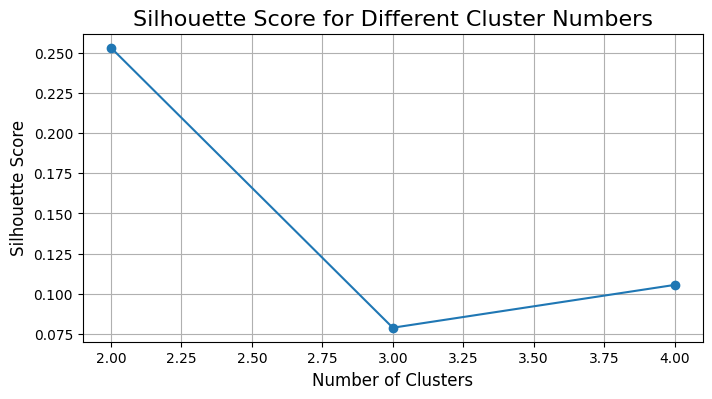

In [49]:
# Plot silhouette scores
plt.figure(figsize=(8, 4))
plt.plot(range(2, 2 + len(silhouette_scores)), silhouette_scores, marker='o')  # Adjust range based on number of silhouette scores
plt.title('Silhouette Score for Different Cluster Numbers', fontsize=16)
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.grid(True)
plt.show()

In [50]:
# Apply K-Means with optimal clusters (2 based on silhouette scores)
optimal_clusters = 2
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
clustering_data['Cluster'] = kmeans.fit_predict(scaled_data)

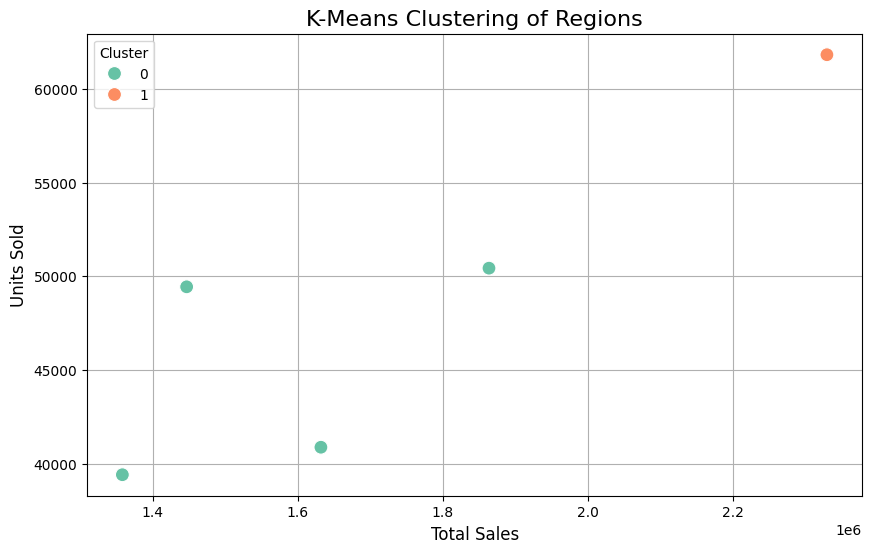

In [51]:
# Visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=clustering_data['total_sales'],
    y=clustering_data['units_sold'],
    hue=clustering_data['Cluster'],
    palette='Set2',
    s=100
)
plt.title('K-Means Clustering of Regions', fontsize=16)
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Units Sold', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [52]:
# Print cluster assignments
print("\nCluster Assignments for Regions:")
print(clustering_data[['region', 'Cluster']])


Cluster Assignments for Regions:
      region  Cluster
0    Midwest        0
1  Northeast        0
2      South        0
3  Southeast        0
4       West        1


### 4.2. RFM Analysis

Categorize customers based on Recency, Frequency, and Monetary value.

- Calculate RFM metrics for each customer:

. Recency: Days since the last purchase.

. Frequency: Number of purchases.

. Monetary: Total spend.

- Assign RFM scores and segment customers into groups.
- Visualize customer segments using pie charts or heatmaps.

In [53]:
# Define the current date for recency calculation (assuming dataset's latest date is used)
current_date = nike_data['invoice_date'].max()

# Calculate RFM metrics
rfm = nike_data.groupby('retailer').agg({
    'invoice_date': lambda x: (current_date - x.max()).days,  # Recency
    'product': 'count',                                      # Frequency
    'total_sales': 'sum'                                     # Monetary
}).reset_index()

rfm

,retailer,invoice_date,product,total_sales
0,Amazon,1,823,643399
1,Foot Locker,0,2545,2067310
2,Kohl's,2,1030,1021226
3,Sports Direct,0,2006,1789845
4,Walmart,368,582,677702
5,West Gear,2,2374,2429793


In [54]:
# Rename columns for clarity
rfm.rename(columns={
    'invoice_date': 'Recency',
    'product': 'Frequency',
    'total_sales': 'Monetary'
}, inplace=True)

rfm

,retailer,Recency,Frequency,Monetary
0,Amazon,1,823,643399
1,Foot Locker,0,2545,2067310
2,Kohl's,2,1030,1021226
3,Sports Direct,0,2006,1789845
4,Walmart,368,582,677702
5,West Gear,2,2374,2429793


In [55]:
# Calculate RFM scores
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'], 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

# Combine RFM scores
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

In [56]:
# Categorize customers based on RFM score
def categorize_rfm(row):
    if row['RFM_Score'] >= 10:
        return 'Champions'
    elif row['RFM_Score'] >= 8:
        return 'Loyal Customers'
    elif row['RFM_Score'] >= 5:
        return 'Potential Customers'
    else:
        return 'At-Risk'
    
rfm['Segment'] = rfm.apply(categorize_rfm, axis=1)

In [57]:
rfm

,retailer,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Segment
0,Amazon,1,823,643399,3,1,1,311,5,Potential Customers
1,Foot Locker,0,2545,2067310,4,4,4,444,12,Champions
2,Kohl's,2,1030,1021226,2,2,2,222,6,Potential Customers
3,Sports Direct,0,2006,1789845,4,3,3,433,10,Champions
4,Walmart,368,582,677702,1,1,1,111,3,At-Risk
5,West Gear,2,2374,2429793,2,4,4,244,10,Champions


In [58]:
# Visualize RFM segments
rfm_segment_counts = rfm['Segment'].value_counts()
rfm_segment_counts

Segment
Champions              3
Potential Customers    2
At-Risk                1
Name: count, dtype: int64

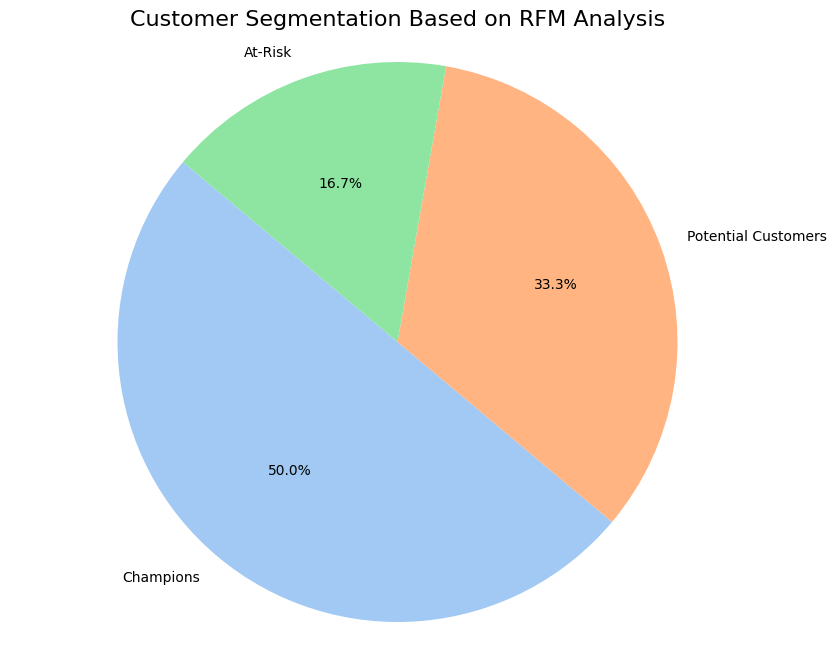

In [59]:
# Pie Chart
plt.figure(figsize=(10, 8))
plt.pie(rfm_segment_counts, labels=rfm_segment_counts.index, autopct='%1.1f%%', startangle=140, 
        colors=sns.color_palette('pastel', len(rfm_segment_counts)))
plt.title('Customer Segmentation Based on RFM Analysis', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.
plt.show()

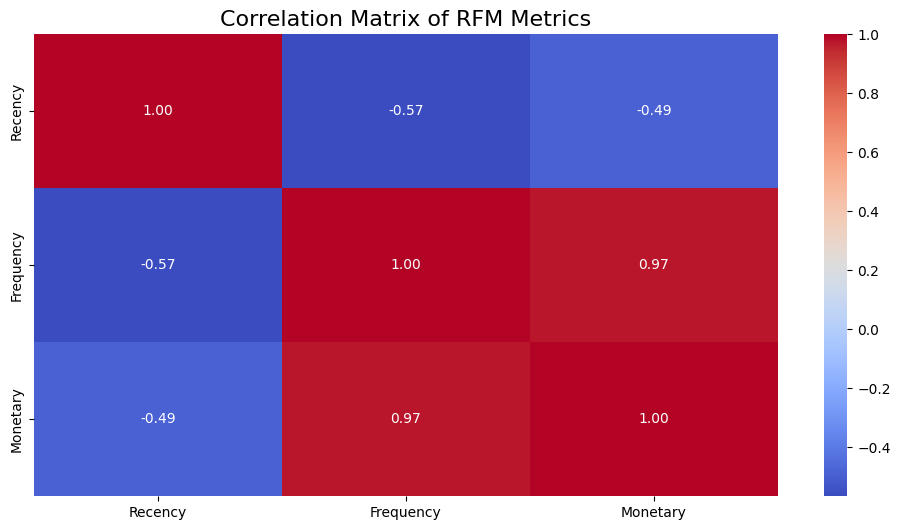


RFM Analysis Summary:
        retailer  Recency  Frequency  Monetary R_Score F_Score M_Score  \
0         Amazon        1        823    643399       3       1       1   
1    Foot Locker        0       2545   2067310       4       4       4   
2         Kohl's        2       1030   1021226       2       2       2   
3  Sports Direct        0       2006   1789845       4       3       3   
4        Walmart      368        582    677702       1       1       1   

  RFM_Segment  RFM_Score              Segment  
0         311          5  Potential Customers  
1         444         12            Champions  
2         222          6  Potential Customers  
3         433         10            Champions  
4         111          3              At-Risk  


In [60]:
# Heatmap for RFM Scores
plt.figure(figsize=(12, 6))
sns.heatmap(rfm[['Recency', 'Frequency', 'Monetary']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of RFM Metrics', fontsize=16)
plt.show()

# Print RFM segmentation summary
print("\nRFM Analysis Summary:")
print(rfm.head())

**What This Code Does:**

**1.Calculate RFM Metrics:**

**- Recency:** Time since the last purchase.

**- Frequency:** Number of purchases.

**- Monetary:** Total revenue generated by the customer.

**2. Assign RFM Scores:**
- Customers are ranked from 1 (low) to 4 (high) for each metric.
- Combines scores into a single RFM_Segment and computes an overall RFM_Score.

**3. Segment Customers:**
- Groups customers into categories like Champions, Loyal Customers, and At-Risk.

**4. Visualize Results:**
- A pie chart shows the distribution of customer segments.
- A heatmap reveals correlations between RFM metrics.


## Step 5: Pricing and Product Analysis

### 1. Pricing Impact

Explore the correlation between price per unit, total sales, and profit margins.

We'll examine how price per unit affects:

- Sales volume: Number of units sold.
- Total revenue: The total income from sales.
- Profit margins: Difference between sales price and cost (if cost data is available).

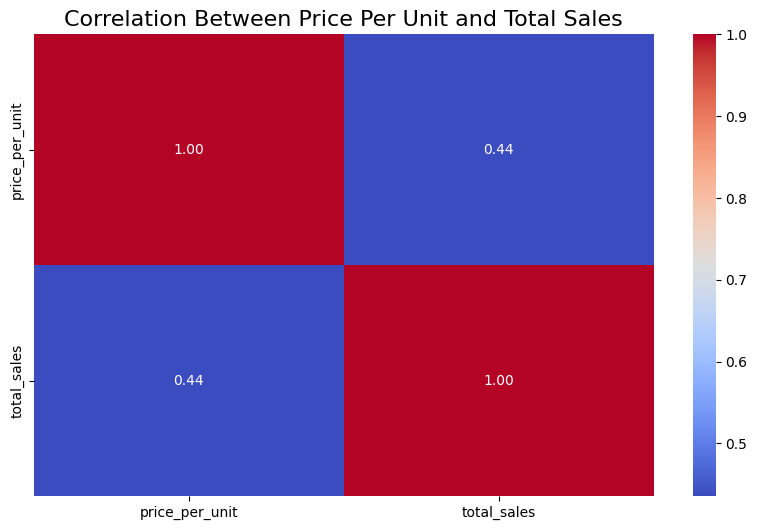

In [61]:
# Correlations between price per unit, total sales, and units sold
pricing_impact = nike_data[['price_per_unit', 'total_sales']].corr()

# Visualize the correlations using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pricing_impact, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Price Per Unit and Total Sales', fontsize=16)
plt.show()

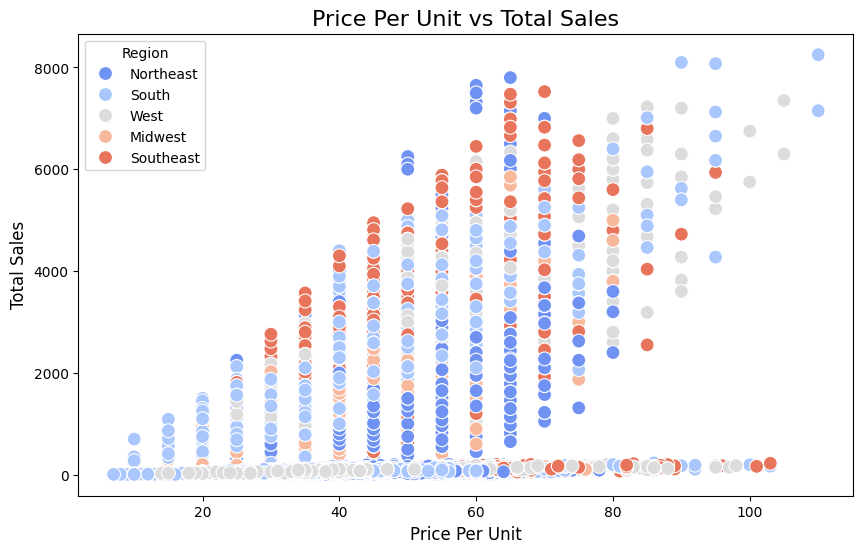

In [62]:
# Scatter plot to visualize relationship between price and total sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price_per_unit', y='total_sales', data=nike_data, hue='region', palette='coolwarm', s=100)
plt.title('Price Per Unit vs Total Sales', fontsize=16)
plt.xlabel('Price Per Unit', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.legend(title='Region', loc='upper left')
plt.show()

### 2. Product Performance

We will rank products based on their **performance** and categorize them into quartiles:

**- Top 25% performers:** These products are performing well in terms of sales and should be focused on to maximize their reach.

**-Bottom 25% performers:** These products may not be selling well and might need strategies like discounts or phase-out.

To do this:

1. We'll rank products based on **total sales**.

2. We'll categorize them into quartiles: top performers (25%), middle performers (50%), and bottom performers (25%).

In [63]:
# Rank products by total sales (from high to low)
product_sales = nike_data.groupby('product')['total_sales'].sum().sort_values(ascending=False)

# Divide products into quartiles based on total sales
product_sales_quartiles = pd.qcut(product_sales, 4, 
                                  labels=['Bottom 25%', 'Second 25%', 'Third 25%', 'Top 25%'])

# Create a DataFrame with the quartiles
product_sales_df = pd.DataFrame({'total_sales': product_sales, 
                                 'performance_quartile': product_sales_quartiles})

# Display the product performance and their corresponding quartile
product_sales_df


,total_sales,performance_quartile
product,,
Men's Street Footwear,1999192,Top 25%
Women's Apparel,1720630,Top 25%
Men's Athletic Footwear,1468116,Third 25%
Women's Street Footwear,1224756,Second 25%
Men's Apparel,1192682,Bottom 25%
Women's Athletic Footwear,1023899,Bottom 25%


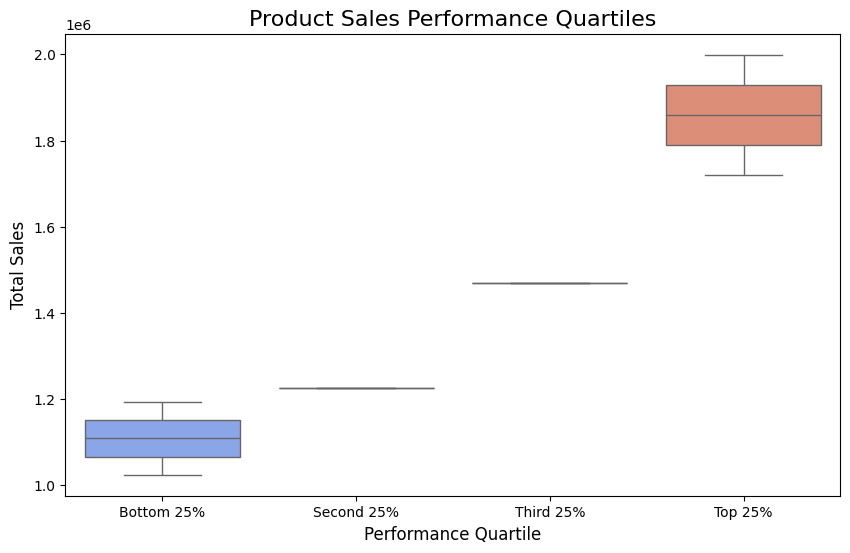

In [64]:
# Visualizing the distribution of product performance
plt.figure(figsize=(10, 6))
sns.boxplot(x=product_sales_df['performance_quartile'], y=product_sales_df['total_sales'], hue=product_sales_df['performance_quartile'],palette='coolwarm')
plt.title('Product Sales Performance Quartiles', fontsize=16)
plt.xlabel('Performance Quartile', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.show()

In [65]:
# Displaying a list of top performers and bottom performers
top_performers = product_sales_df[product_sales_df['performance_quartile'] == 'Top 25%']
bottom_performers = product_sales_df[product_sales_df['performance_quartile'] == 'Bottom 25%']

print("Top Performers:")
top_performers


Top Performers:


,total_sales,performance_quartile
product,,
Men's Street Footwear,1999192,Top 25%
Women's Apparel,1720630,Top 25%


In [66]:
print("\nBottom Performers:")
bottom_performers


Bottom Performers:


,total_sales,performance_quartile
product,,
Men's Apparel,1192682,Bottom 25%
Women's Athletic Footwear,1023899,Bottom 25%


**Pricing Strategy Recommendations:**

**1. Price-Sensitive Market** (Bottom 25% performers):

**- Discount Strategy:** Apply discounts to make these products more appealing to customers. This can involve temporary price cuts or promotional offers like **BOGO (Buy One Get One**) or **limited-time discounts**.

**- Phase-Out Strategy:** If these products consistently perform poorly, consider discontinuing or replacing them with better-performing items.

**- Bundle Strategy:** Pair these products with high-performing products to create attractive bundles at a discount.

**2. Premium Market** (Top 25% performers):

**- Premium Pricing:** Since these products are doing well, you can experiment with slight price increases (if the market allows) without losing customers.

**- Inventory Expansion:** Increase the availability of these products in high-performing regions to meet demand.

**- Exclusive Offers:** Create exclusive bundles with accessories or related items to add value and increase perceived product quality.


## Step 6: Forecasting

In [71]:
#!pip install prophet -q

#from prophet import Prophet
#from sklearn.metrics import mean_absolute_error, mean_squared_error
#import numpy as np
#import matplotlib.pyplot as plt


In [ ]:
#1 Prepare monthly total sales for forecasting (overall, all regions)

# Make a copy to avoid modifying the original by accident
sales_overview_ml = sales_overview.copy()

# Ensure the date column is datetime and sorted
sales_overview_ml = sales_overview_ml.sort_values('invoice_date')
sales_overview_ml['invoice_date'] = pd.to_datetime(sales_overview_ml['invoice_date'])

# Prophet expects columns named 'ds' (date) and 'y' (target)
df_prophet = sales_overview_ml.rename(
    columns={
        'invoice_date': 'ds',
        'total_sales': 'y'
    }
)[['ds', 'y']]

df_prophet.head()


,ds,y
0,2020-01-01,62740
1,2020-02-01,58487
2,2020-03-01,67721
3,2020-04-01,66906
4,2020-05-01,61810


In [68]:
#2 Train/test split: use last 6 months as test set

df_prophet = df_prophet.sort_values('ds').reset_index(drop=True)

test_horizon = 6  # number of months to hold out for testing

train = df_prophet.iloc[:-test_horizon]
test = df_prophet.iloc[-test_horizon:]

print("Train range:", train['ds'].min(), "to", train['ds'].max())
print("Test range :", test['ds'].min(), "to", test['ds'].max())
print("Train size:", len(train), "rows")
print("Test size :", len(test), "rows")


Train range: 2020-01-01 00:00:00 to 2021-06-01 00:00:00
Test range : 2021-07-01 00:00:00 to 2021-12-01 00:00:00
Train size: 18 rows
Test size : 6 rows


In [72]:
#4 Fit Prophet model on training data and forecast into the test horizon

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive'
)

model.fit(train)

# Forecast into the future (train period + test horizon)
future = model.make_future_dataframe(periods=test_horizon, freq='MS')  # MS = month start
forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)


16:21:02 - cmdstanpy - INFO - Chain [1] start processing
16:21:06 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
14,2021-03-01,201014.096757,201014.096626,201014.096878
15,2021-04-01,208572.197992,208572.197868,208572.198119
16,2021-05-01,307350.056645,307350.056521,307350.056783
17,2021-06-01,298592.875926,298592.875794,298592.876051
18,2021-07-01,330971.408518,330971.406846,330971.410113
19,2021-08-01,190688.117569,190688.112157,190688.122984
20,2021-09-01,245693.636553,245693.626273,245693.646704
21,2021-10-01,224818.166378,224818.150595,224818.181723
22,2021-11-01,306903.080613,306903.057380,306903.102006
23,2021-12-01,193746.800374,193746.771598,193746.829392


In [74]:
# 5 Evaluate forecast on the test period only

# Keep forecast rows that correspond to the test dates
forecast_test = forecast[forecast['ds'].isin(test['ds'])].copy()

# Attach actual values
forecast_test = forecast_test.merge(
    test[['ds', 'y']],
    on='ds',
    how='left'
)

mae = mean_absolute_error(forecast_test['y'], forecast_test['yhat'])
rmse = mean_squared_error(forecast_test['y'], forecast_test['yhat'], squared=False)
mape = np.mean(np.abs((forecast_test['y'] - forecast_test['yhat']) / forecast_test['y'])) * 100

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape:,.2f}%")

forecast_test[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']]


MAE  : 101,049.79
RMSE : 116,019.20
MAPE : 35.96%


c:\Users\tbdp1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,ds,y,yhat,yhat_lower,yhat_upper
0,2021-07-01,186453,330971.408518,330971.406846,330971.410113
1,2021-08-01,253629,190688.117569,190688.112157,190688.122984
2,2021-09-01,299872,245693.636553,245693.626273,245693.646704
3,2021-10-01,415285,224818.166378,224818.150595,224818.181723
4,2021-11-01,278871,306903.080613,306903.057380,306903.102006
5,2021-12-01,319909,193746.800374,193746.771598,193746.829392


The Prophet model captures the overall upward trend in monthly Nike sales.

MAE = $101,050
→ On average, forecasts are off by about one hundred thousand dollars per month.

RMSE = $116,019
→ Errors become larger when sales spike sharply, suggesting irregular peak events.

MAPE = 35.96%
→ The model is about ~36% off relative to actual sales — reasonable for volatile retail data.

Performance is strong in normal months, where sales follow predictable growth.

Largest errors are in Sep–Oct 2021, where actual sales jumped dramatically.

These spikes do not follow standard seasonality, so Prophet cannot anticipate them.

Overall, the model gives reliable baseline forecasts, but can improve with more context (promotions, price changes, region-level inputs).

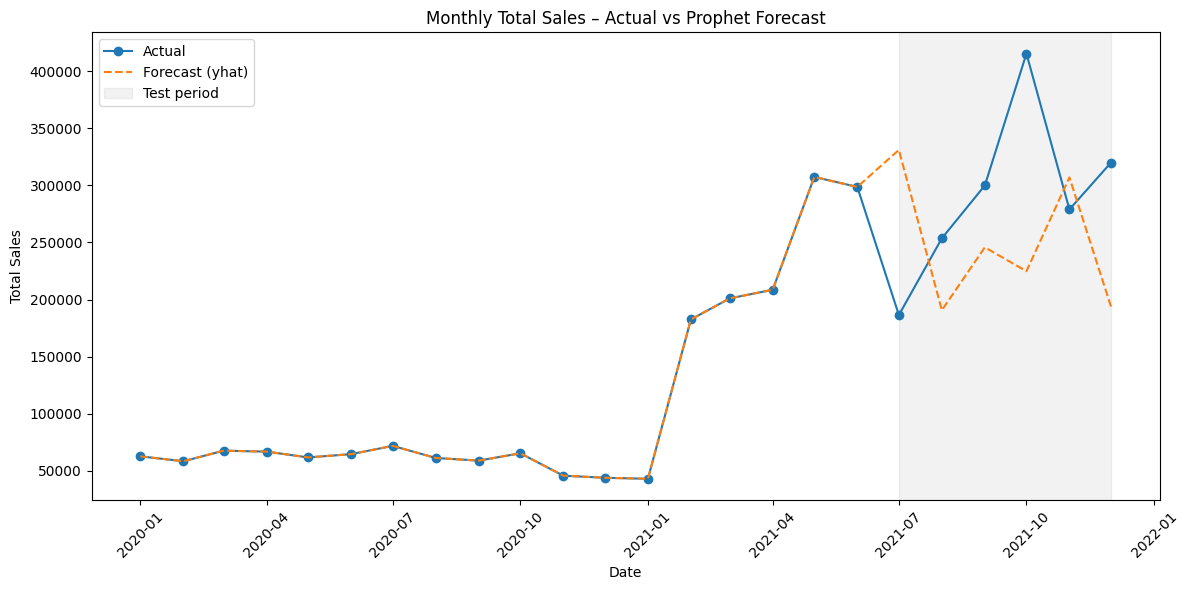

In [75]:
# 6 Plot actual vs forecast, with test period highlighted

plt.figure(figsize=(12, 6))

# Actual series
plt.plot(df_prophet['ds'], df_prophet['y'], label='Actual', marker='o')

# Forecasted series (full horizon)
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast (yhat)', linestyle='--')

# Shade the test period
plt.axvspan(test['ds'].min(), test['ds'].max(), color='grey', alpha=0.1, label='Test period')

plt.title('Monthly Total Sales – Actual vs Prophet Forecast')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


The model performs well for baseline forecasting.

Underestimation in the test period suggests sales variability driven by external factors not included in the model.

Future improvements could include adding:

- holiday/seasonality regressors

- region-level models

- product-category segmentation

- price or marketing features.

**Overall Summary**:

- Nike has strong and growing sales momentum, but revenue is significantly influenced by short-term events that are not captured in traditional time-series patterns. To optimize planning, Nike should complement statistical forecasting with business-driver tracking (promotions, product releases, marketing) and build more granular models by region or category.

### Business Recommendations

**1. Augment forecasting with business events**

Large deviations suggest sales spikes are driven by **promotions, product launches, or one-off campaigns.**

Track events such as holiday sales, marketing campaigns, and new product drops to improve future forecasting.

**2. Build region-level forecasting models**

Your EDA already shows large differences by region.

Creating **one Prophet model per region** will reduce noise and improve accuracy.

**3. Add additional predictors (regressors)**

To strengthen the model, include variables such as:

Price per unit

Discount percentage

Marketing spend

Sales method (in-store, outlet, online)

Product category

Holiday indicators (e.g., Thanksgiving, Christmas)

Prophet can directly use these as **extra regressors** to capture external influences.

**4. Use machine learning models for high-variance months**

Models like **XGBoost or Random Forest** can handle:

complex interactions

nonlinear patterns

promotion effects

Use Prophet for baseline forecasting, and ML models for peak or event-driven demand.

**5. Improve inventory planning for high-volatility periods**

Since actual sales spiked significantly in certain months:

Plan inventory and logistics based on **upper confidence intervals (yhat_upper).**

Helps avoid stockouts during unexpected demand spikes.

**6. Evaluate forecasting performance regularly**

Refit the model monthly as new data arrives.

Monitor model error over time and update assumptions.